# Data Cleaning & Processing

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

I need to convert columns to their correct data-types.
Why? Because i wont be able to perform mathematical operations with non-numericals.

Pandas has a method that infers the correct type of data -> .convert_dtypes()
I don't want to do it manually like this: df['Age'] = pd.to_numeric(df['Age'])
Important Note: The method doesn't apply to datetime. -> Must do seperate operation.

In [73]:
df = pd.read_csv("messy_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.convert_dtypes()

I will drop duplicates early.
Dropping duplicates early means invalid data wont be included in mathematical operations later on.

It's smart to check if the duplicates aren't just rows that coniciedently share the same data.
.duplicated() checks for ID duplicates, so no two ID's can co-exist at the same time (must be unique) therefore i remove them.

In [74]:
print(f'Duplicates BEFORE removing: {df.duplicated(subset=['ID']).sum()}')
df = df.drop_duplicates(subset=['ID'])
print(f'Duplicates AFTER removing: {df.duplicated().sum()}')

Duplicates BEFORE removing: 500
Duplicates AFTER removing: 0


I can use skewness as the first step to determine if i use mean or median to replace empty cells.

If the data is right skewed (aka positive skewed) then most data points are on the left with few large values pushing the distribution to the right.
If the data is left skewed (aka negative skewed) then most data points are on the right with few large values pushing the distrubtion to the left.

The more appropriate average is median if the distribution is right-skewed or left-skewed as outliers will pull down or push the true value of the mean.
(Thresholds: -0.5 < skew  or skew > 0.5 )

No skewness / negligable skewness means i will use mean because no outliers are distorting the mean.
(skewness ≈ 0).

In [75]:
columns = ['Age','Sales','Profit','Discount']
for col in columns:
    skew = df[col].skew()

    if skew > 0.5:
        print(f'{col}: is left skewed, use median')

    elif skew < -0.5:
        print(f'{col}: is right skewed, use median')

    else:
        print(f'{col}: has no skew use mean')

Age: has no skew use mean
Sales: has no skew use mean
Profit: has no skew use mean
Discount: has no skew use mean


Before i use the mean i will check for outliers.  
Why? To see the mean is being distorted by outliers.  
(Using the IQR method (interquartile range method))  

In [76]:
columns = ['Age','Sales','Profit','Discount']
for col in columns:
    quartile1 = df[col].quantile(0.25)
    quartile3 = df[col].quantile(0.75)

    IQR =  quartile3 - quartile1

    lower_bound = quartile1 - (1.5 * IQR)
    upper_bound = quartile3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Sales: 0 outliers
Profit: 0 outliers
Discount: 0 outliers


No outliers detected.  
It's safe to use the mean to the fill the empty cells.  
I will round to the closest whole number as the result may be a very long float numeric.  
(Pandas likely infered int for the columns not float so filling in anything but an int would raise an error)

For catergorial data like gender i can replace null values with either the mode or my own value.
I will just replace null values with 'Unknown'.

For category i will remove the rows.
Why? The data is useless now, a business or an individual can interpret nothing from sales figures if it's unknown what is being sold.

In [77]:
df[columns] = df[columns].fillna(df[columns].mean().round())
df['Gender'] = df['Gender'].fillna('Unknown')
df.dropna(subset=['Category'], inplace=True)

Lastly for the cleaned dataset i will export it into a CSV file before i continue working with the data

In [78]:
df.to_csv("cleaned_data.csv", index=False)

# Data Wrangling & Transformation

The data is clean.  
I can now perform some operations using formulas to get some useful information.   
Such as the following: 
- TOTAL SALES
- TOTAL PROFIT
- Profit Margin
- Profit after discounts
- Total revenue lost to discounts

Can also provide time-frames for the data averages i.e.: Annualy, monthly, weekly, daily.

.groupby() method will split the data into groups based on criteria (category).
.reset_index() method will provide the categorys an index rather than being the index.

Note: im unsure if sales is the sales revenue or the individual product count sold by the people.
I will assume its sales revenue

Exta note: I learned Pandas uses vectorised operations to process data which proccesses entire columns in one go, this is faster.
Therefore i chose to ignore lambdas but i will add them in comments to show i can use them for success criteria.

In [79]:
sales_summary = df.groupby('Category')['Sales'].sum().reset_index()

df['Profit Margin'] = (df['Profit'] / df['Sales']).round(decimals=2)  # or df["Profit Margin"] = df["Profit"].apply(lambda x: x / df["Sales"] if x and df["Sales"].sum() != 0 else 0)
df['Revenue Lost'] =  (df['Sales'] * df['Discount'] / 100).round(decimals=2) # or df["Revenue Lost"] = df["Sales"].apply(lambda x: x * df["Discount"] if x and df["Discount"].sum() !=0 else 0)
df['Net Profit'] = (df['Profit'] - df['Revenue Lost']).round(decimals=2)# or df["Net Profit"] = df["Profit"].apply(lambda x: x - df["Revenue Lost"] if x and df["Revenue Lost"].sum() !=0 else 0)
total_Revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_revenue_lost = df['Revenue Lost'].sum()
total_net_profit = df['Net Profit'].sum()

print(df)
print()
print(f'\ntotal revenue: {total_Revenue}')
print(f'\ntotal profit: {total_profit}')
print(f'\ntotal revenue lost: {total_revenue_lost}')
print(f'\ntotal net profit: {total_net_profit}')

        ID     Name  Age   Gender  Sales  Profit       Date     Category  \
0        1    David   25   Female    100      30 2023-01-01      Grocery   
1        2      Eve   27   Female    248      10 2023-01-01     Clothing   
2        3  Charlie   35    Other    248      30 2023-01-01  Electronics   
3        4      Eve   35  Unknown    248      10        NaT     Clothing   
4        5      Eve   27     Male    100      10 2023-02-15  Electronics   
...    ...      ...  ...      ...    ...     ...        ...          ...   
4992  4993      Eve   25   Female    400      10 2023-01-01  Electronics   
4994  4995      Bob   30     Male    248      10        NaT     Clothing   
4996  4997    David   30     Male    300      25        NaT    Furniture   
4998  4999    David   35     Male    248      25 2023-01-01      Grocery   
4999  5000      Eve   30     Male    100      40        NaT      Grocery   

      Discount  Profit Margin  Revenue Lost  Net Profit  
0           20            0.3

The data for the business isn't looking good.  
This is because the net profit is negative.  
The business is incurring a loss after discounts, likely due to discounts as its the only column that can reduce the profit.

# Exploratory Data Analysis
I need to identify correlations between numeric values and use pivot table sto analyse trends.  
I had an issue where .describe would be printed unneatly due to date pushing the heading/ columns. I excluded string columns to make data more readable.  
I had an error where the .corr() method was reading my string columns the way i handled this was to enable true for numeric_only = True in parameters.  

In [80]:
print(df.describe(include=['number']))

                ID       Age       Sales     Profit  Discount  Profit Margin  \
count       3907.0    3907.0      3907.0     3907.0    3907.0         3907.0   
mean   2519.177886  27.29204  249.522396  24.874584  12.65677       0.122629   
std    1444.810359  5.015077   99.425179   10.09794  4.982374       0.086785   
min            1.0      20.0       100.0       10.0       5.0           0.02   
25%         1263.5      25.0       200.0       20.0      10.0           0.06   
50%         2546.0      27.0       248.0       25.0      13.0            0.1   
75%         3779.0      30.0       300.0       30.0      15.0           0.15   
max         5000.0      35.0       400.0       40.0      20.0            0.4   

       Revenue Lost  Net Profit  
count        3907.0      3907.0  
mean       31.63484   -6.760256  
std       18.540638    21.05171  
min             5.0       -70.0  
25%            15.0       -20.0  
50%            30.0        -5.0  
75%            40.0        10.0  
max    

A correlation matrix will measure how related two variables are.
X - Explanatory variable  
Y - Response variable  
Correlation is within the ranges of -1 to 1.  
perfect negative correlation is -1  
perfect positive correlation is 1  
no correlation is 0.


In [81]:
correlation_matrix = df.corr(method="pearson", min_periods=1, numeric_only=True)
print(correlation_matrix)

                     ID       Age     Sales    Profit  Discount  \
ID             1.000000 -0.045465 -0.014663  0.017736 -0.015597   
Age           -0.045465  1.000000  0.002240  0.003605 -0.001141   
Sales         -0.014663  0.002240  1.000000 -0.007710  0.010775   
Profit         0.017736  0.003605 -0.007710  1.000000  0.018812   
Discount      -0.015597 -0.001141  0.010775  0.018812  1.000000   
Profit Margin  0.016902  0.003653 -0.688575  0.583298  0.001519   
Revenue Lost  -0.013896  0.002387  0.685600  0.006808  0.683892   
Net Profit     0.020746 -0.000373 -0.607519  0.473677 -0.593293   

               Profit Margin  Revenue Lost  Net Profit  
ID                  0.016902     -0.013896    0.020746  
Age                 0.003653      0.002387   -0.000373  
Sales              -0.688575      0.685600   -0.607519  
Profit              0.583298      0.006808    0.473677  
Discount            0.001519      0.683892   -0.593293  
Profit Margin       1.000000     -0.465420    0.689696

A pivot table is a way to summarise your data by grouping it.  
This will let you see patterns move clearly.  
This will help me see how discounts can affect sales and other patterns.

In [82]:
sales_pivot = df.pivot_table(values='Sales', index='Category', columns='Discount',aggfunc="sum")
age_pivot = df.pivot_table(values='Sales', index='Category', columns='Age', aggfunc='sum')
lost_revenue = df.pivot_table(values='Revenue Lost', index='Category',columns='Discount', aggfunc='sum')
discount_profit = df.pivot_table(values='Net Profit', index='Category', columns='Discount', aggfunc='sum')
print(f'\n--Sales and Discount--\n{sales_pivot}')
print(f'\n--Sales and Age--\n{age_pivot}')
print(f'\n--Discount and Revenue lost--\n{lost_revenue}')
print(f'\n--Discount and Net Profit--\n{discount_profit}')


--Sales and Discount--
Discount        5      10     13     15     20
Category                                      
Clothing     47032  45324  51384  46260  50716
Electronics  45672  41680  52712  53464  50960
Furniture    50872  51112  46024  44880  47824
Grocery      48428  48920  52224  49620  49776

--Sales and Age--
Age             20     25     27     30     35
Category                                      
Clothing     42976  48628  51476  52708  44928
Electronics  54504  51456  50864  43280  44384
Furniture    51980  50916  46928  44468  46420
Grocery      49764  49020  49980  45036  55168

--Discount and Revenue lost--
Discount         5       10       13      15       20
Category                                             
Clothing     2351.6  4532.4  6679.92  6939.0  10143.2
Electronics  2283.6  4168.0  6852.56  8019.6  10192.0
Furniture    2543.6  5111.2  5983.12  6732.0   9564.8
Grocery      2421.4  4892.0  6789.12  7443.0   9955.2

--Discount and Net Profit--
Discount 

### Sales and Discount pivot table
The data is fluctuating up and down.  
This confirms there is no meaningful correlation from the correlation matrix of 0.010775 between sales and discount.    
  
Sales and Discount have a 0.010775 correlation.   
  
Such a small correlation is seen as negligible / unmeaningful in statisitcs.

### Sales and Age pivot table
We can view which age demographic is our biggest spenders.  
Each cateogry has their appeal for different age groups.  
This data could be used by a marketing team to target each demographic.  

clothing -> biggest spenders ages 27-30  
electronics -> biggest spenders age 20  
furniture -> biggest spenders age 20-25 
grocery -> biggest spenders age 35  

### Discount and revenue lost pivot table
Can identify if discounts is a good trade-off.    
There is a clear linear pattern.    
Positive correlation of 0.683892. -> Seen as a strong positive correlation.  

Question to ask: is this a good trade-off?  
Discounts brings an incentive to buy more goods which increases total sales, but this comes at the trade-off of higher revenue lost.  
The business should optimise discounts to gain the max amount of profits without losing too much revenue. (objective for business: find equilibrium / optimal balance)  

### Discount and Net Profit pivot table
This will show us the relationship between discount and net profit.  
As we calculated previoulsy we saw we incurred a net loss.

There is a clear linear downward pattern. 
This is reinforced by strong negative correlation of -0.593293

The business is clearly not benefitting from these discounts as no category is incurring a positive net profit after discounts.


# Data Visualisation

I will create the following graphs for each appropriate column:  
- Line graphs  
- bar charts  
- Scatter plot  

Line graphs to view trends.  
Scatterplot to see correlation/ relationship between columns.
Bar charts to compare two columns

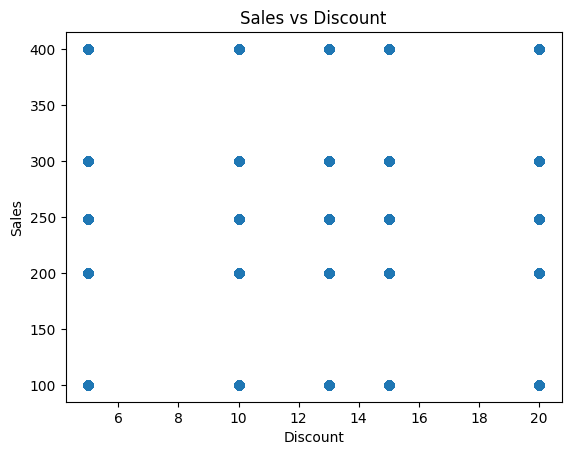

In [83]:
#scatterplot sales and discount

plt.scatter(df['Discount'],df['Sales'])
plt.title('Sales vs Discount')
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.show()


Prompt: why does the scatterplot look weird?  
The graph appeared structured rather than random because both variables contain discrete,  
repeated values (e.g. fixed discount levels and repeated sales figures).  
this causes multiple data points to overlap at the same coordinates, forming a grid-like pattern.  
  
I was confused as ive never seen a scatterplot like this.  

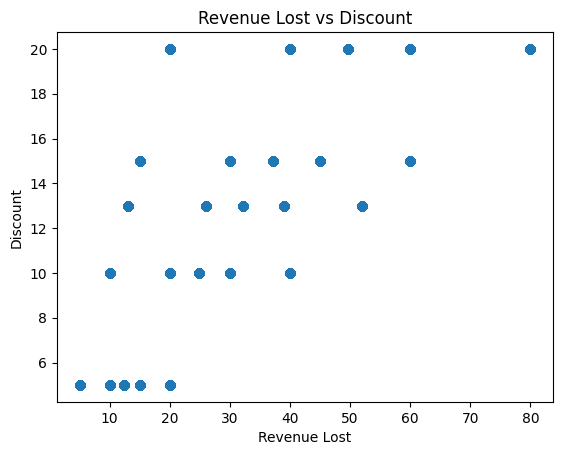

In [84]:
#scatterplot Revenue lost and discount

plt.scatter(df['Revenue Lost'],df['Discount'])
plt.title('Revenue Lost vs Discount')
plt.xlabel('Revenue Lost')
plt.ylabel('Discount')
plt.show()

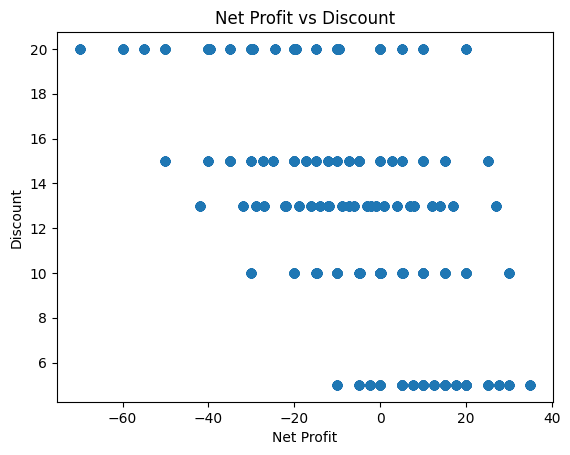

In [85]:
#scatterplot Net Profit vs Discount

plt.scatter(df['Net Profit'],df['Discount'])
plt.title('Net Profit vs Discount')
plt.xlabel('Net Profit')
plt.ylabel('Discount')
plt.show()

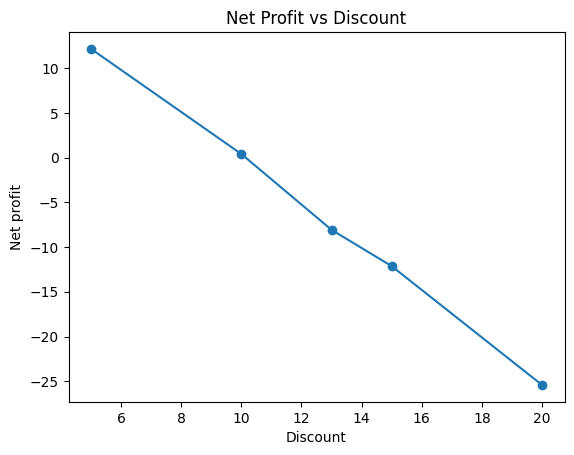

In [86]:
#Line graph Discount and net profit

#My line graph had an insane mess so i prompted gpt to help me understand why.
#prompt: why is my data line plot messy?
#it was because i used a line graph on the raw data which connected EVERY POINT IN ORDER.
#By making an average for each discount column it gave me one value per discount column.
#This made the graph look clean.
avg_profit = df.groupby('Discount')['Net Profit'].mean()

plt.plot(avg_profit.index, avg_profit.values, marker='o')
plt.title('Net Profit vs Discount')
plt.xlabel('Discount')
plt.ylabel('Net profit')
plt.show()

This graph shows great insight for the business.  
We break-even when discount is at 10%.
Anything higher the business makes a net loss.  
This is the key information the business needs!  
The business should continue discounting only if its below 10%.  

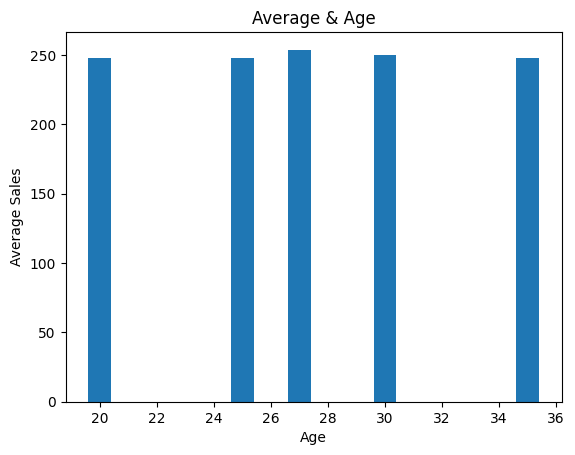

In [87]:
avg_sales_age = df.groupby('Age')['Sales'].mean()

plt.bar(avg_sales_age.index, avg_sales_age.values)
plt.title('Average & Age')
plt.xlabel('Age')
plt.ylabel('Average Sales')
plt.show()

Overall we can our biggest spenders are between 26-28 on average.  
By a small margin though.  
Its better to view this by category.  

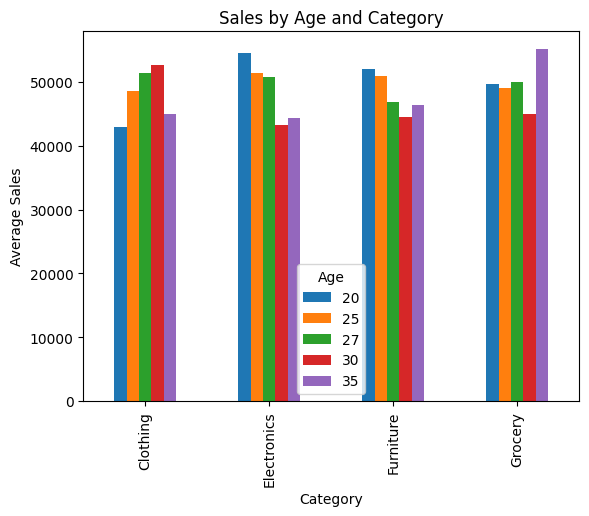

In [88]:
age_pivot.plot(kind='bar')
plt.title('Sales by Age and Category')
plt.ylabel('Average Sales')
plt.show()